In [2]:
# Cell 1: Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Configure visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12, 'axes.titlesize': 14})

# Mount Drive and load dataset
drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/Finlens/data/processed/Finlens_dataset.csv'
df = pd.read_csv(FILE_PATH, engine='python', quotechar='"', on_bad_lines='skip')

# Calculate length metrics for NLP analysis
df['word_count'] = df['cleaned_clause_text'].astype(str).apply(lambda x: len(x.split()))

print("[+] Dataset loaded successfully.")

Mounted at /content/drive
[+] Dataset loaded successfully.


In [3]:
df.head()

,clause_id,document_id,provider_name,document_type,source_type,raw_text,cleaned_clause_text,violation_category,risk_level,violating_span,primary_law_reference,annotator_notes,word_count
0,CLS_10341482,DOC_A580C6EF,Tala,terms_and_conditions,official_website,Tala Loan App Kenya | Line of Credit Agreement...,Tala Loan App Kenya | Line of Credit Agreement...,COMPLIANT,0,NaN,NOT_APPLICABLE,Standard provision. No explicit violation of C...,37
1,CLS_D9FAFBD9,DOC_A580C6EF,Tala,terms_and_conditions,official_website,The applicable interest is determined on a ris...,The applicable interest is determined on a ris...,COMPLIANT,0,NaN,NOT_APPLICABLE,Standard provision. No explicit violation of C...,10
2,CLS_032F62B4,DOC_A580C6EF,Tala,terms_and_conditions,official_website,TALA KENYA: LINE OF CREDIT AGREEMENT,TALA KENYA: LINE OF CREDIT AGREEMENT,COMPLIANT,0,NaN,NOT_APPLICABLE,Standard provision. No explicit violation of C...,6
3,CLS_4E225AD4,DOC_A580C6EF,Tala,terms_and_conditions,official_website,The following terms and conditions apply to th...,The following to the Tala Line of Credit (the ...,COMPLIANT,0,NaN,NOT_APPLICABLE,Standard provision. No explicit violation of C...,30
4,CLS_CB331E16,DOC_A580C6EF,Tala,terms_and_conditions,official_website,The Service allows all new and existing Tala C...,The Service allows all new and existing Tala C...,COMPLIANT,0,NaN,NOT_APPLICABLE,Standard provision. No explicit violation of C...,22


In [4]:
# Cell 2: Baseline EDA Statistics
total_clauses = len(df)
total_providers = df['provider_name'].nunique()
total_documents = df['document_id'].nunique()
doc_types = df['document_type'].nunique()
compliant_count = (df['risk_level'] == 0).sum()
non_compliant_count = (df['risk_level'] > 0).sum()
violation_cats = df[df['violation_category'] != 'COMPLIANT']['violation_category'].nunique()
duplicate_clauses = df.duplicated(subset=['cleaned_clause_text']).sum()
missing_values = df.isnull().sum().sum()

print("="*40)
print("FINLENS DATASET OVERVIEW")
print("="*40)
print(f"Total Clauses: {total_clauses:,}")
print(f"Unique Providers: {total_providers}")
print(f"Source Documents: {total_documents}")
print(f"Document Types: {doc_types}")
print("-" * 40)
print(f"Compliant Clauses: {compliant_count:,} ({compliant_count/total_clauses:.1%})")
print(f"Non-Compliant Clauses: {non_compliant_count:,} ({non_compliant_count/total_clauses:.1%})")
print(f"Violation Categories: {violation_cats}")
print("-" * 40)
print(f"Duplicate Texts (Boilerplate): {duplicate_clauses:,}")
print(f"Total Missing Values: {missing_values}")
print("="*40)

FINLENS DATASET OVERVIEW
Total Clauses: 9,467
Unique Providers: 56
Source Documents: 94
Document Types: 5
----------------------------------------
Compliant Clauses: 9,379 (99.1%)
Non-Compliant Clauses: 88 (0.9%)
Violation Categories: 6
----------------------------------------
Duplicate Texts (Boilerplate): 459
Total Missing Values: 9379


/tmp/ipykernel_2805/2673702054.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax[0], palette=['#2ca02c', '#d62728'])
/tmp/ipykernel_2805/2673702054.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax[1], palette='Reds_r')


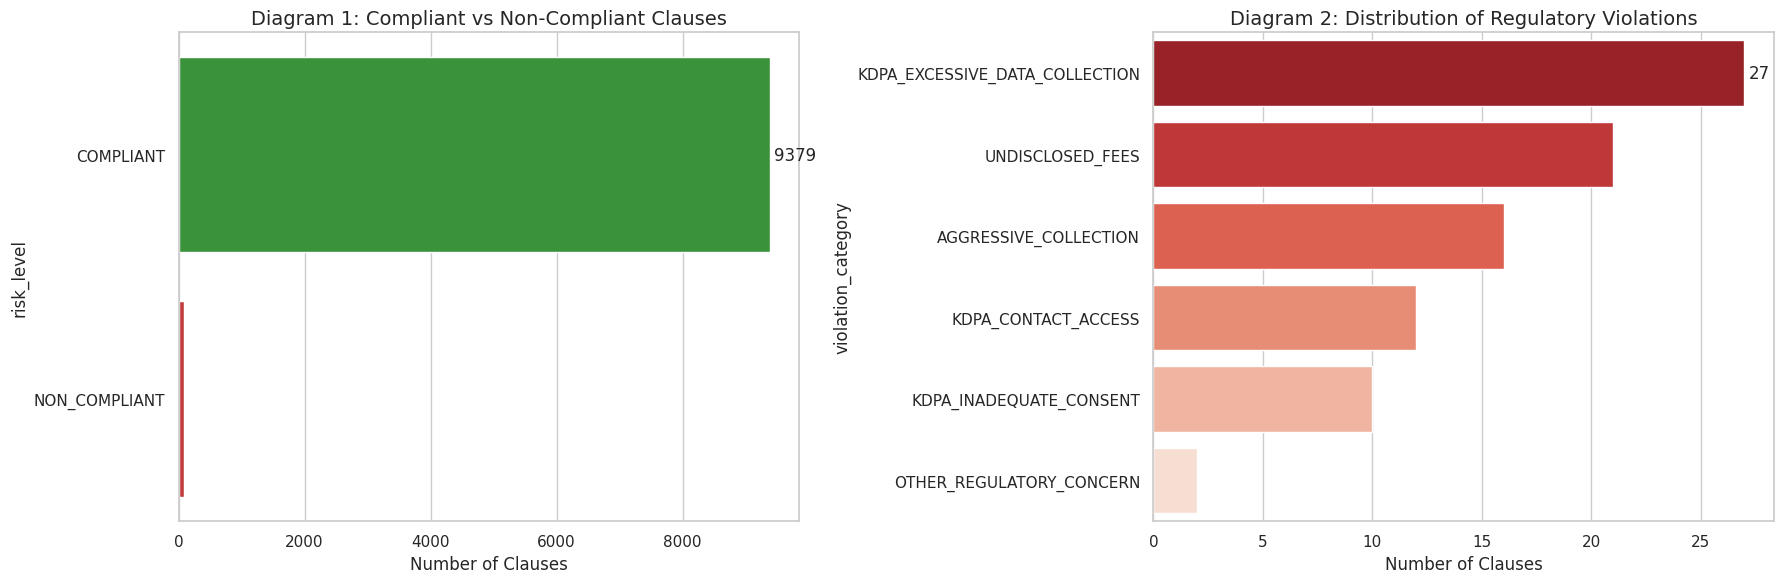

In [5]:
# Cell 3: Class Imbalance and Violation Typology
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Diagram 1: Compliant vs Non-Compliant
class_counts = df['risk_level'].apply(lambda x: 'COMPLIANT' if x == 0 else 'NON_COMPLIANT').value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax[0], palette=['#2ca02c', '#d62728'])
ax[0].set_title('Diagram 1: Compliant vs Non-Compliant Clauses')
ax[0].set_xlabel('Number of Clauses')
ax[0].bar_label(ax[0].containers[0], padding=3)

# Diagram 2: Non-Compliance Categories
violations_df = df[df['violation_category'] != 'COMPLIANT']
cat_counts = violations_df['violation_category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax[1], palette='Reds_r')
ax[1].set_title('Diagram 2: Distribution of Regulatory Violations')
ax[1].set_xlabel('Number of Clauses')
ax[1].bar_label(ax[1].containers[0], padding=3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2805/1333909461.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='document_type', order=df['document_type'].value_counts().index, ax=ax[0], palette='Blues_d')
/tmp/ipykernel_2805/1333909461.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='source_type', order=df['source_type'].value_counts().index, ax=ax[1], palette='Oranges_d')


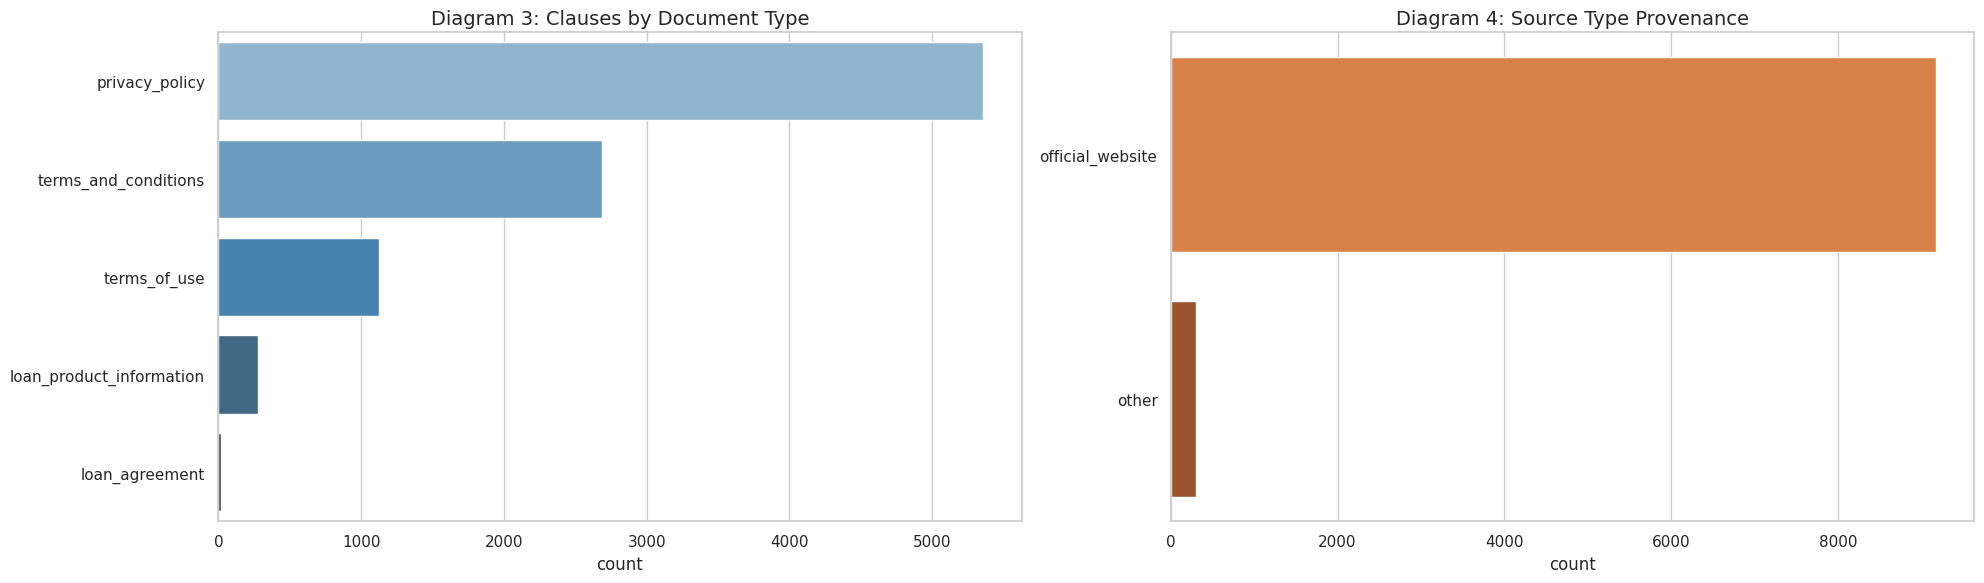

In [6]:
# Cell 4: Structural Distributions
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Diagram 3: Clauses by Document Type
sns.countplot(data=df, y='document_type', order=df['document_type'].value_counts().index, ax=ax[0], palette='Blues_d')
ax[0].set_title('Diagram 3: Clauses by Document Type')
ax[0].set_ylabel('')

# Diagram 4: Source Type Distribution
sns.countplot(data=df, y='source_type', order=df['source_type'].value_counts().index, ax=ax[1], palette='Oranges_d')
ax[1].set_title('Diagram 4: Source Type Provenance')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2805/1902664865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_providers.values, y=top_providers.index, ax=ax[0], palette='Purples_r')


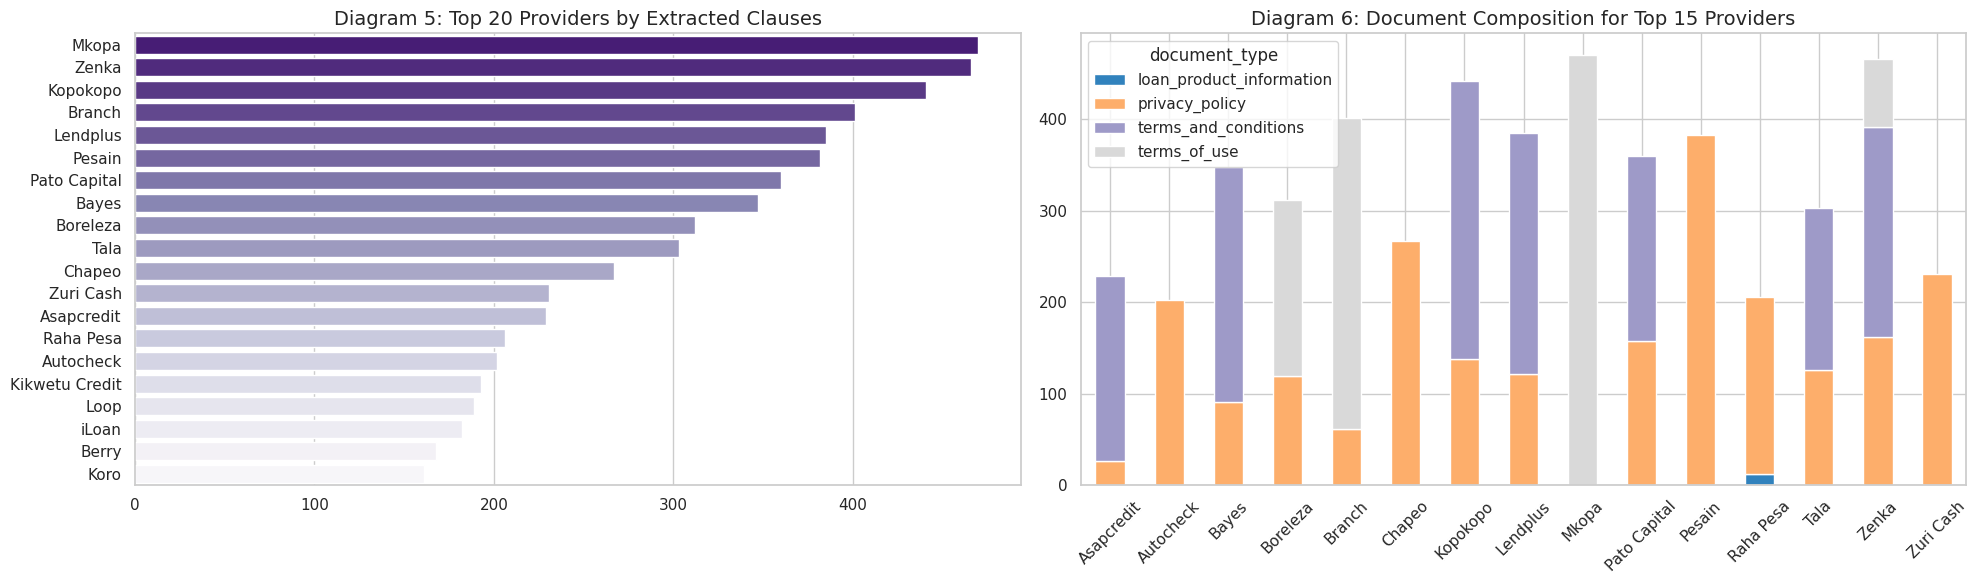

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Diagram 5: Top 20 Providers by Clause Volume
top_providers = df['provider_name'].value_counts().head(20)
sns.barplot(x=top_providers.values, y=top_providers.index, ax=ax[0], palette='Purples_r')
ax[0].set_title('Diagram 5: Top 20 Providers by Extracted Clauses')
ax[0].set_ylabel('')

# Diagram 6: Document Count by Top 15 Providers (Stacked)
top_15 = df['provider_name'].value_counts().head(15).index
doc_provider_crosstab = pd.crosstab(df[df['provider_name'].isin(top_15)]['provider_name'],
                                    df[df['provider_name'].isin(top_15)]['document_type'])
doc_provider_crosstab.plot(kind='bar', stacked=True, ax=ax[1], colormap='tab20c')
ax[1].set_title('Diagram 6: Document Composition for Top 15 Providers')
ax[1].set_xlabel('')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

--- Word Count Descriptive Statistics ---
count    9467.000000
mean       27.081335
std        23.609255
min         6.000000
25%        15.000000
50%        22.000000
75%        32.000000
max       526.000000
Name: word_count, dtype: float64


/tmp/ipykernel_2805/1386131736.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='word_count', y='document_type', ax=ax[1], showfliers=False, palette='Set2')
/tmp/ipykernel_2805/1386131736.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='word_count', y=df['risk_level'].astype(str), ax=ax[2], palette=['#2ca02c', '#d62728'])


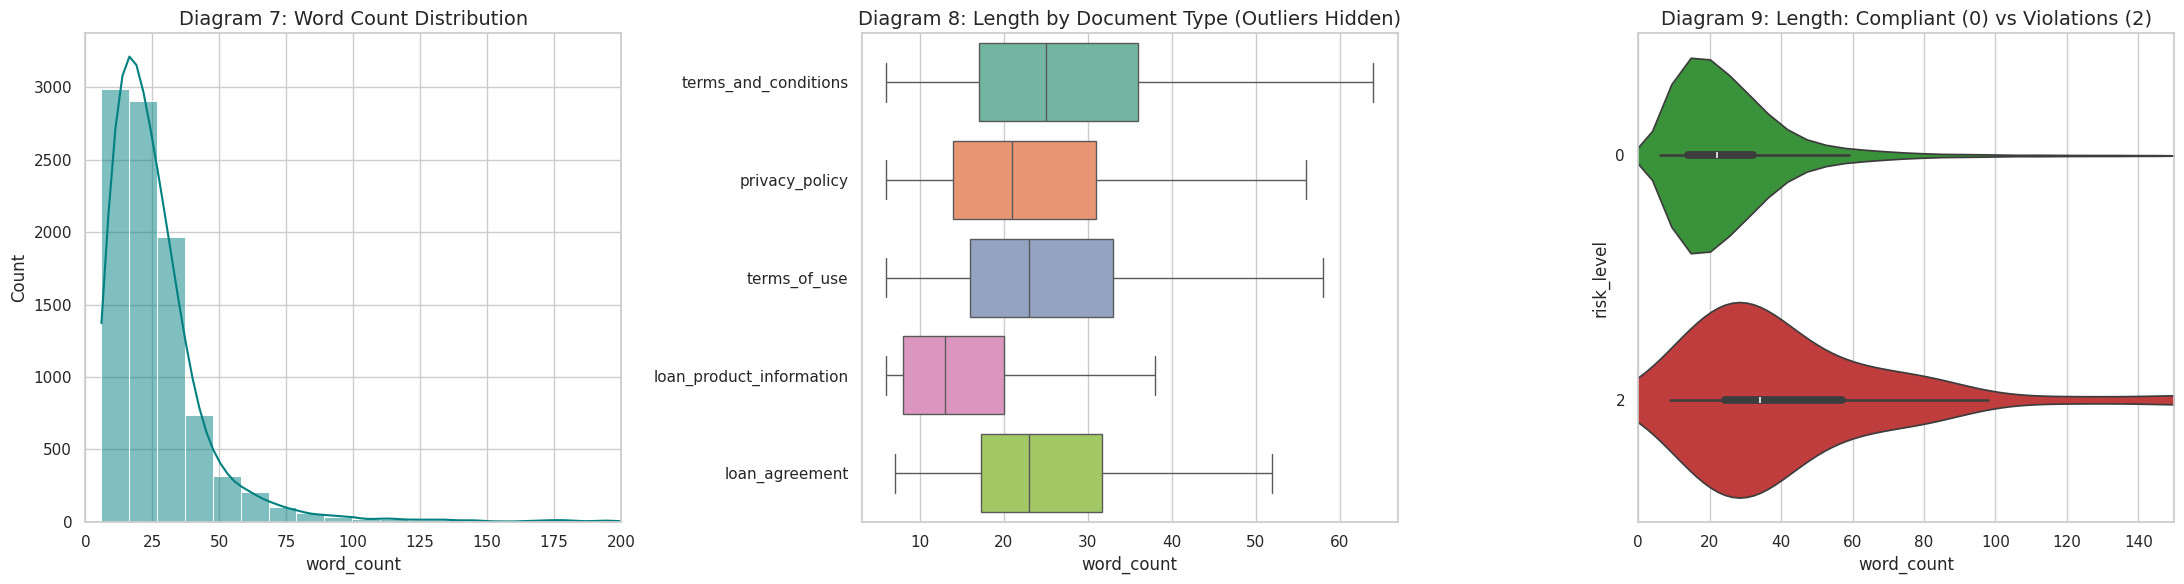

In [8]:
# Cell 5: Clause Length Analysis for BERT Tokenization
print("--- Word Count Descriptive Statistics ---")
print(df['word_count'].describe())

fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Diagram 7: Distribution of Clause Length
sns.histplot(df['word_count'], bins=50, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Diagram 7: Word Count Distribution')
ax[0].set_xlim(0, 200) # Truncate long tail for visibility

# Diagram 8: Length by Document Type
sns.boxplot(data=df, x='word_count', y='document_type', ax=ax[1], showfliers=False, palette='Set2')
ax[1].set_title('Diagram 8: Length by Document Type (Outliers Hidden)')
ax[1].set_ylabel('')

# Diagram 9: Length by Compliance Status
sns.violinplot(data=df, x='word_count', y=df['risk_level'].astype(str), ax=ax[2], palette=['#2ca02c', '#d62728'])
ax[2].set_title('Diagram 9: Length: Compliant (0) vs Violations (2)')
ax[2].set_xlim(0, 150)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2805/2898625246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flagged_providers.values, y=flagged_providers.index, palette='Reds_r')


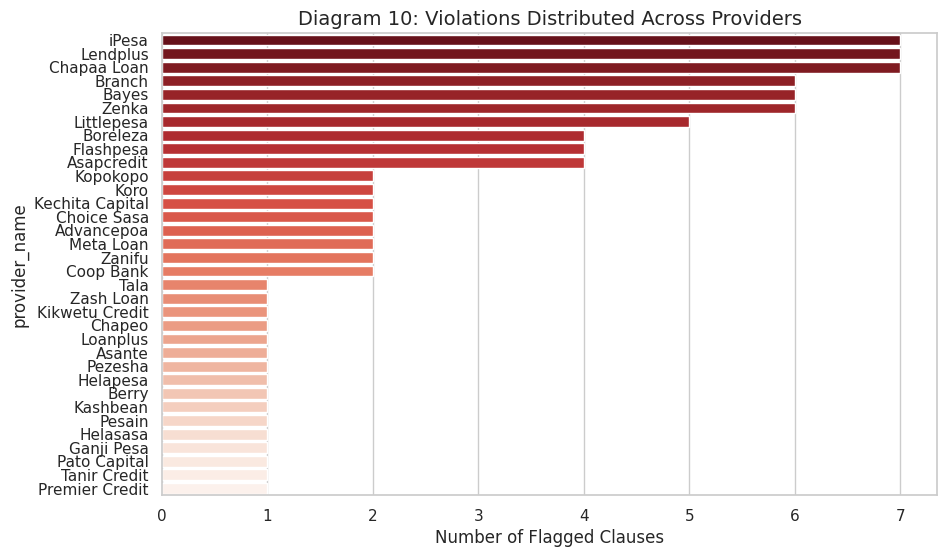

In [9]:
# Diagram 10: Non-Compliant Clauses by Provider (Only offending providers)
flagged_providers = df[df['risk_level'] > 0]['provider_name'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=flagged_providers.values, y=flagged_providers.index, palette='Reds_r')
plt.title("Diagram 10: Violations Distributed Across Providers")
plt.xlabel("Number of Flagged Clauses")
plt.show()

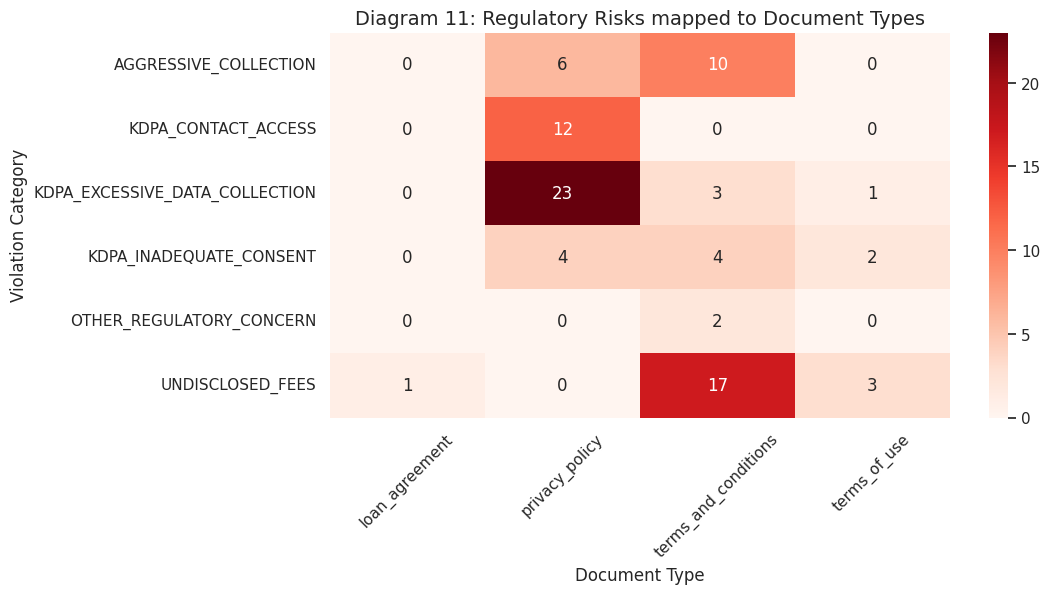

In [10]:
# Diagram 11: Violation Type by Document Type (The Cross-Tabulation Heatmap)
plt.figure(figsize=(10, 5))
heatmap_data = pd.crosstab(violations_df['violation_category'], violations_df['document_type'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', cbar=True)
plt.title("Diagram 11: Regulatory Risks mapped to Document Types")
plt.xlabel("Document Type")
plt.ylabel("Violation Category")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2805/1217218451.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dup_counts, y=['Unique Clauses', 'Duplicate Boilerplate'], ax=ax[1], palette=['blue', 'orange'])


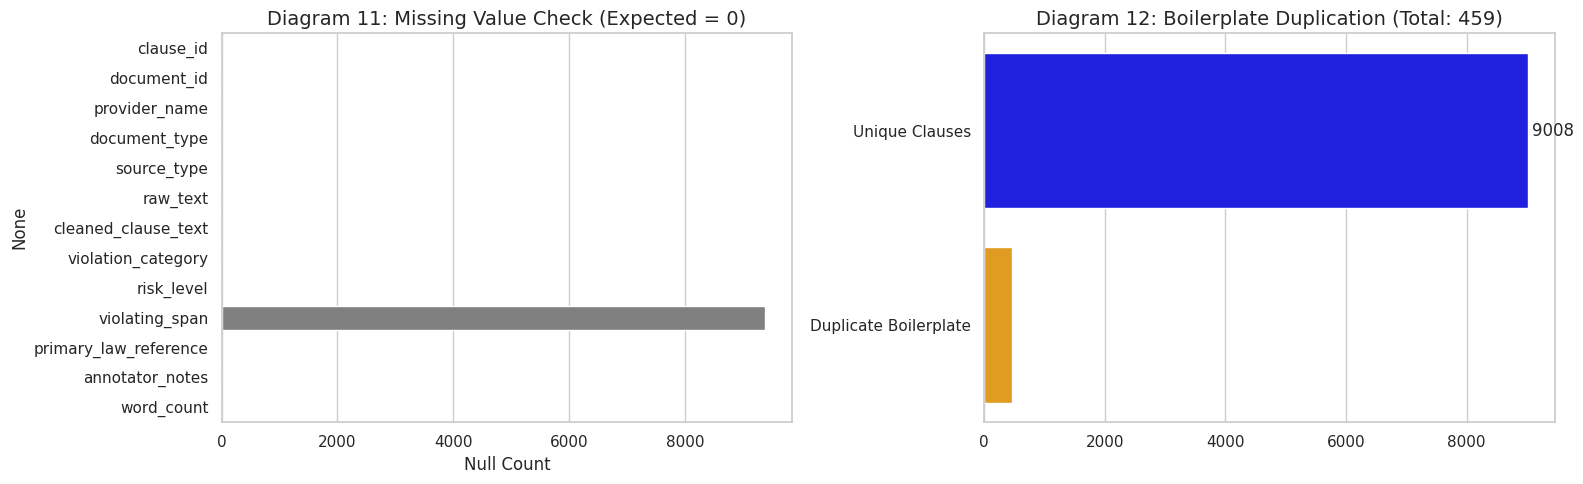

In [11]:
# Cell 7: Missing Values and Duplicates

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Diagram 12: Missing Values (Should be 0 if the dataset is sealed correctly)
missing = df.isnull().sum()
sns.barplot(x=missing.values, y=missing.index, ax=ax[0], color='grey')
ax[0].set_title('Diagram 11: Missing Value Check (Expected = 0)')
ax[0].set_xlabel('Null Count')

# Diagram 13: Duplicate Clause Analysis (Boilerplate)
dup_counts = [len(df) - duplicate_clauses, duplicate_clauses]
sns.barplot(x=dup_counts, y=['Unique Clauses', 'Duplicate Boilerplate'], ax=ax[1], palette=['blue', 'orange'])
ax[1].set_title(f'Diagram 12: Boilerplate Duplication (Total: {duplicate_clauses:,})')
ax[1].bar_label(ax[1].containers[0], padding=3)

plt.tight_layout()
plt.show()

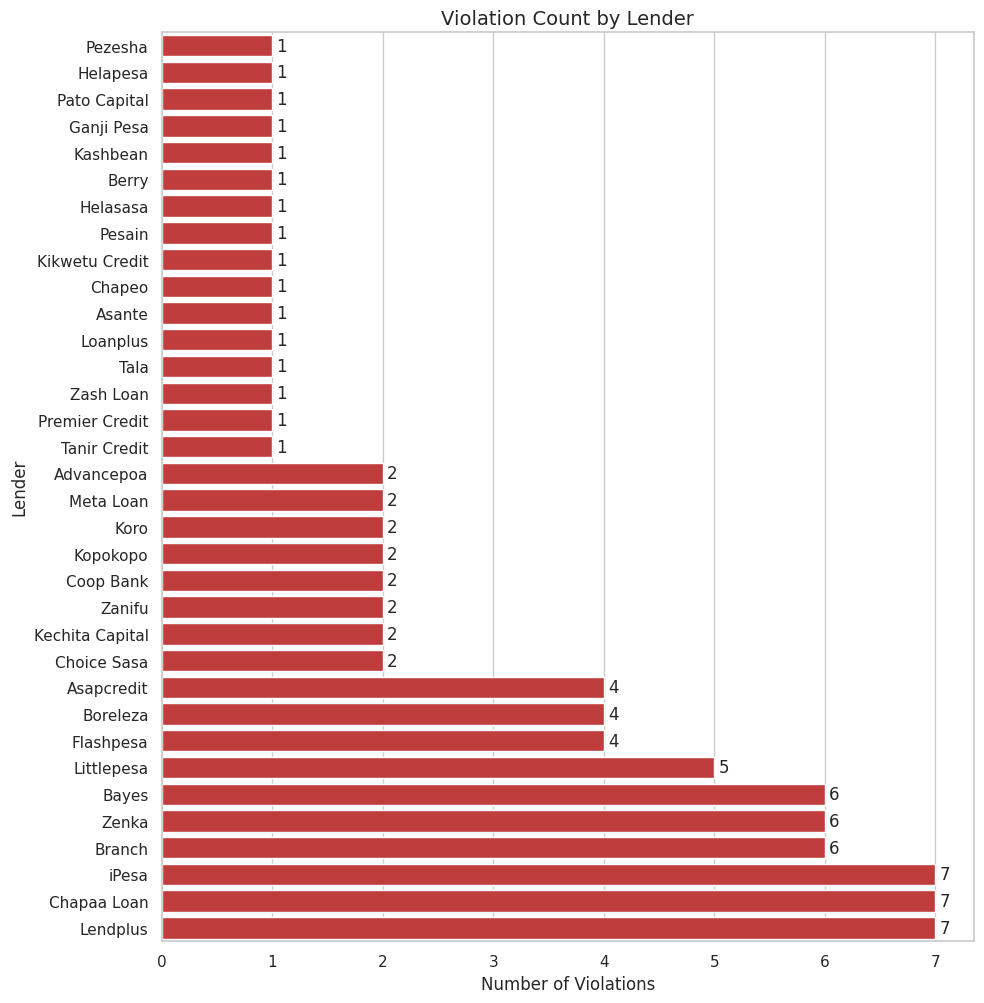

In [12]:
# Violations per lender (providers with at least one violation)
violations_by_lender = violations_df['provider_name'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(violations_by_lender) * 0.3)))
sns.barplot(
    x=violations_by_lender.values,
    y=violations_by_lender.index,
    ax=ax,
    color='#d62728'
)

ax.set_title('Violation Count by Lender')
ax.set_xlabel('Number of Violations')
ax.set_ylabel('Lender')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

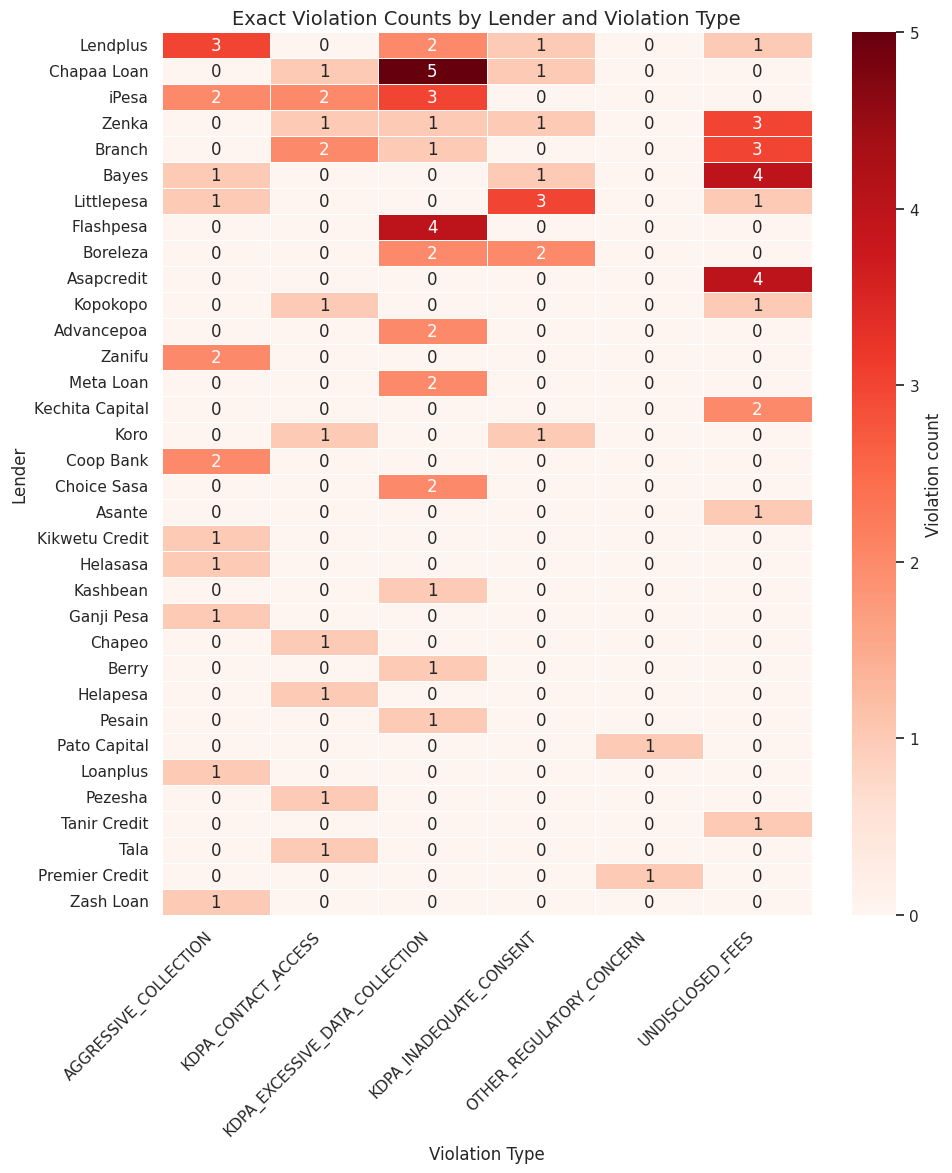

In [15]:
# Exact violation counts by lender and violation category
lender_violation_counts = pd.crosstab(
    violations_df['provider_name'],
    violations_df['violation_category']
)

# Sort lenders by their total violation count
lender_violation_counts = lender_violation_counts.loc[
    lender_violation_counts.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(
    figsize=(10, max(6, len(lender_violation_counts) * 0.35))
)

sns.heatmap(
    lender_violation_counts,
    annot=True,
    fmt='d',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Violation count'},
    ax=ax
)

ax.set_title('Exact Violation Counts by Lender and Violation Type')
ax.set_xlabel('Violation Type')
ax.set_ylabel('Lender')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()